In [1]:
import math
import torch
import torch.nn as nn
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageShow 

In [2]:
# Import autoencoder utility tools
from MNIST.data.parser import train_loader, test_loader, output_to_image
from MNIST.models.ae import AutoEncoder

In [3]:
n_epochs = 20 
lr = 0.001
momentum = 0.9

In [4]:
train_means = np.empty((n_epochs))
test_means = np.empty((n_epochs))

In [5]:
train_batches = len(train_loader)
test_batches = len(test_loader)

In [6]:
# Now i need to define the model and an optimiser
autoencoder = AutoEncoder()
optimiser = torch.optim.SGD(autoencoder.parameters(), lr=lr, momentum=momentum)
criterion = nn.MSELoss()

In [7]:
# Now i need to define the training loop and, inside, the loss function
for epoch in range(n_epochs):
    train_loss = 0
    test_loss = 0
    for i, (x_train, _) in enumerate(train_loader):
        optimiser.zero_grad()
        x_hat = autoencoder(x_train)
        loss = criterion(x_hat, x_train)
        train_loss += loss.item()
        loss.backward()
        optimiser.step()
    train_means[epoch] = train_loss / train_batches
    with torch.inference_mode():
        for j, (x_test, _) in enumerate(test_loader):
            x_hat = autoencoder(x_test)
            loss = criterion(x_hat, x_test)
            test_loss += loss.item()
        test_means[epoch] = test_loss / test_batches
    print(f"\r{f'{epoch+1}/{n_epochs}: {i+1}/{train_batches}':<20}", end='', flush=True)

20/20: 938/938      

# Results

In [18]:
# Here I shall test the model visually, passing an image through,
# denormalising the result and rendering it with pillow
data = next(iter(train_loader))[0][0]

output = autoencoder(torch.reshape(data, (1,1,28,28)))[0][0]
restored_output = output_to_image(output)
img_hat = Image.fromarray(restored_output.detach().numpy())

restored_data = output_to_image(data)[0]
img = Image.fromarray(restored_data.numpy())
ImageShow.show(img_hat)
ImageShow.show(img)

True

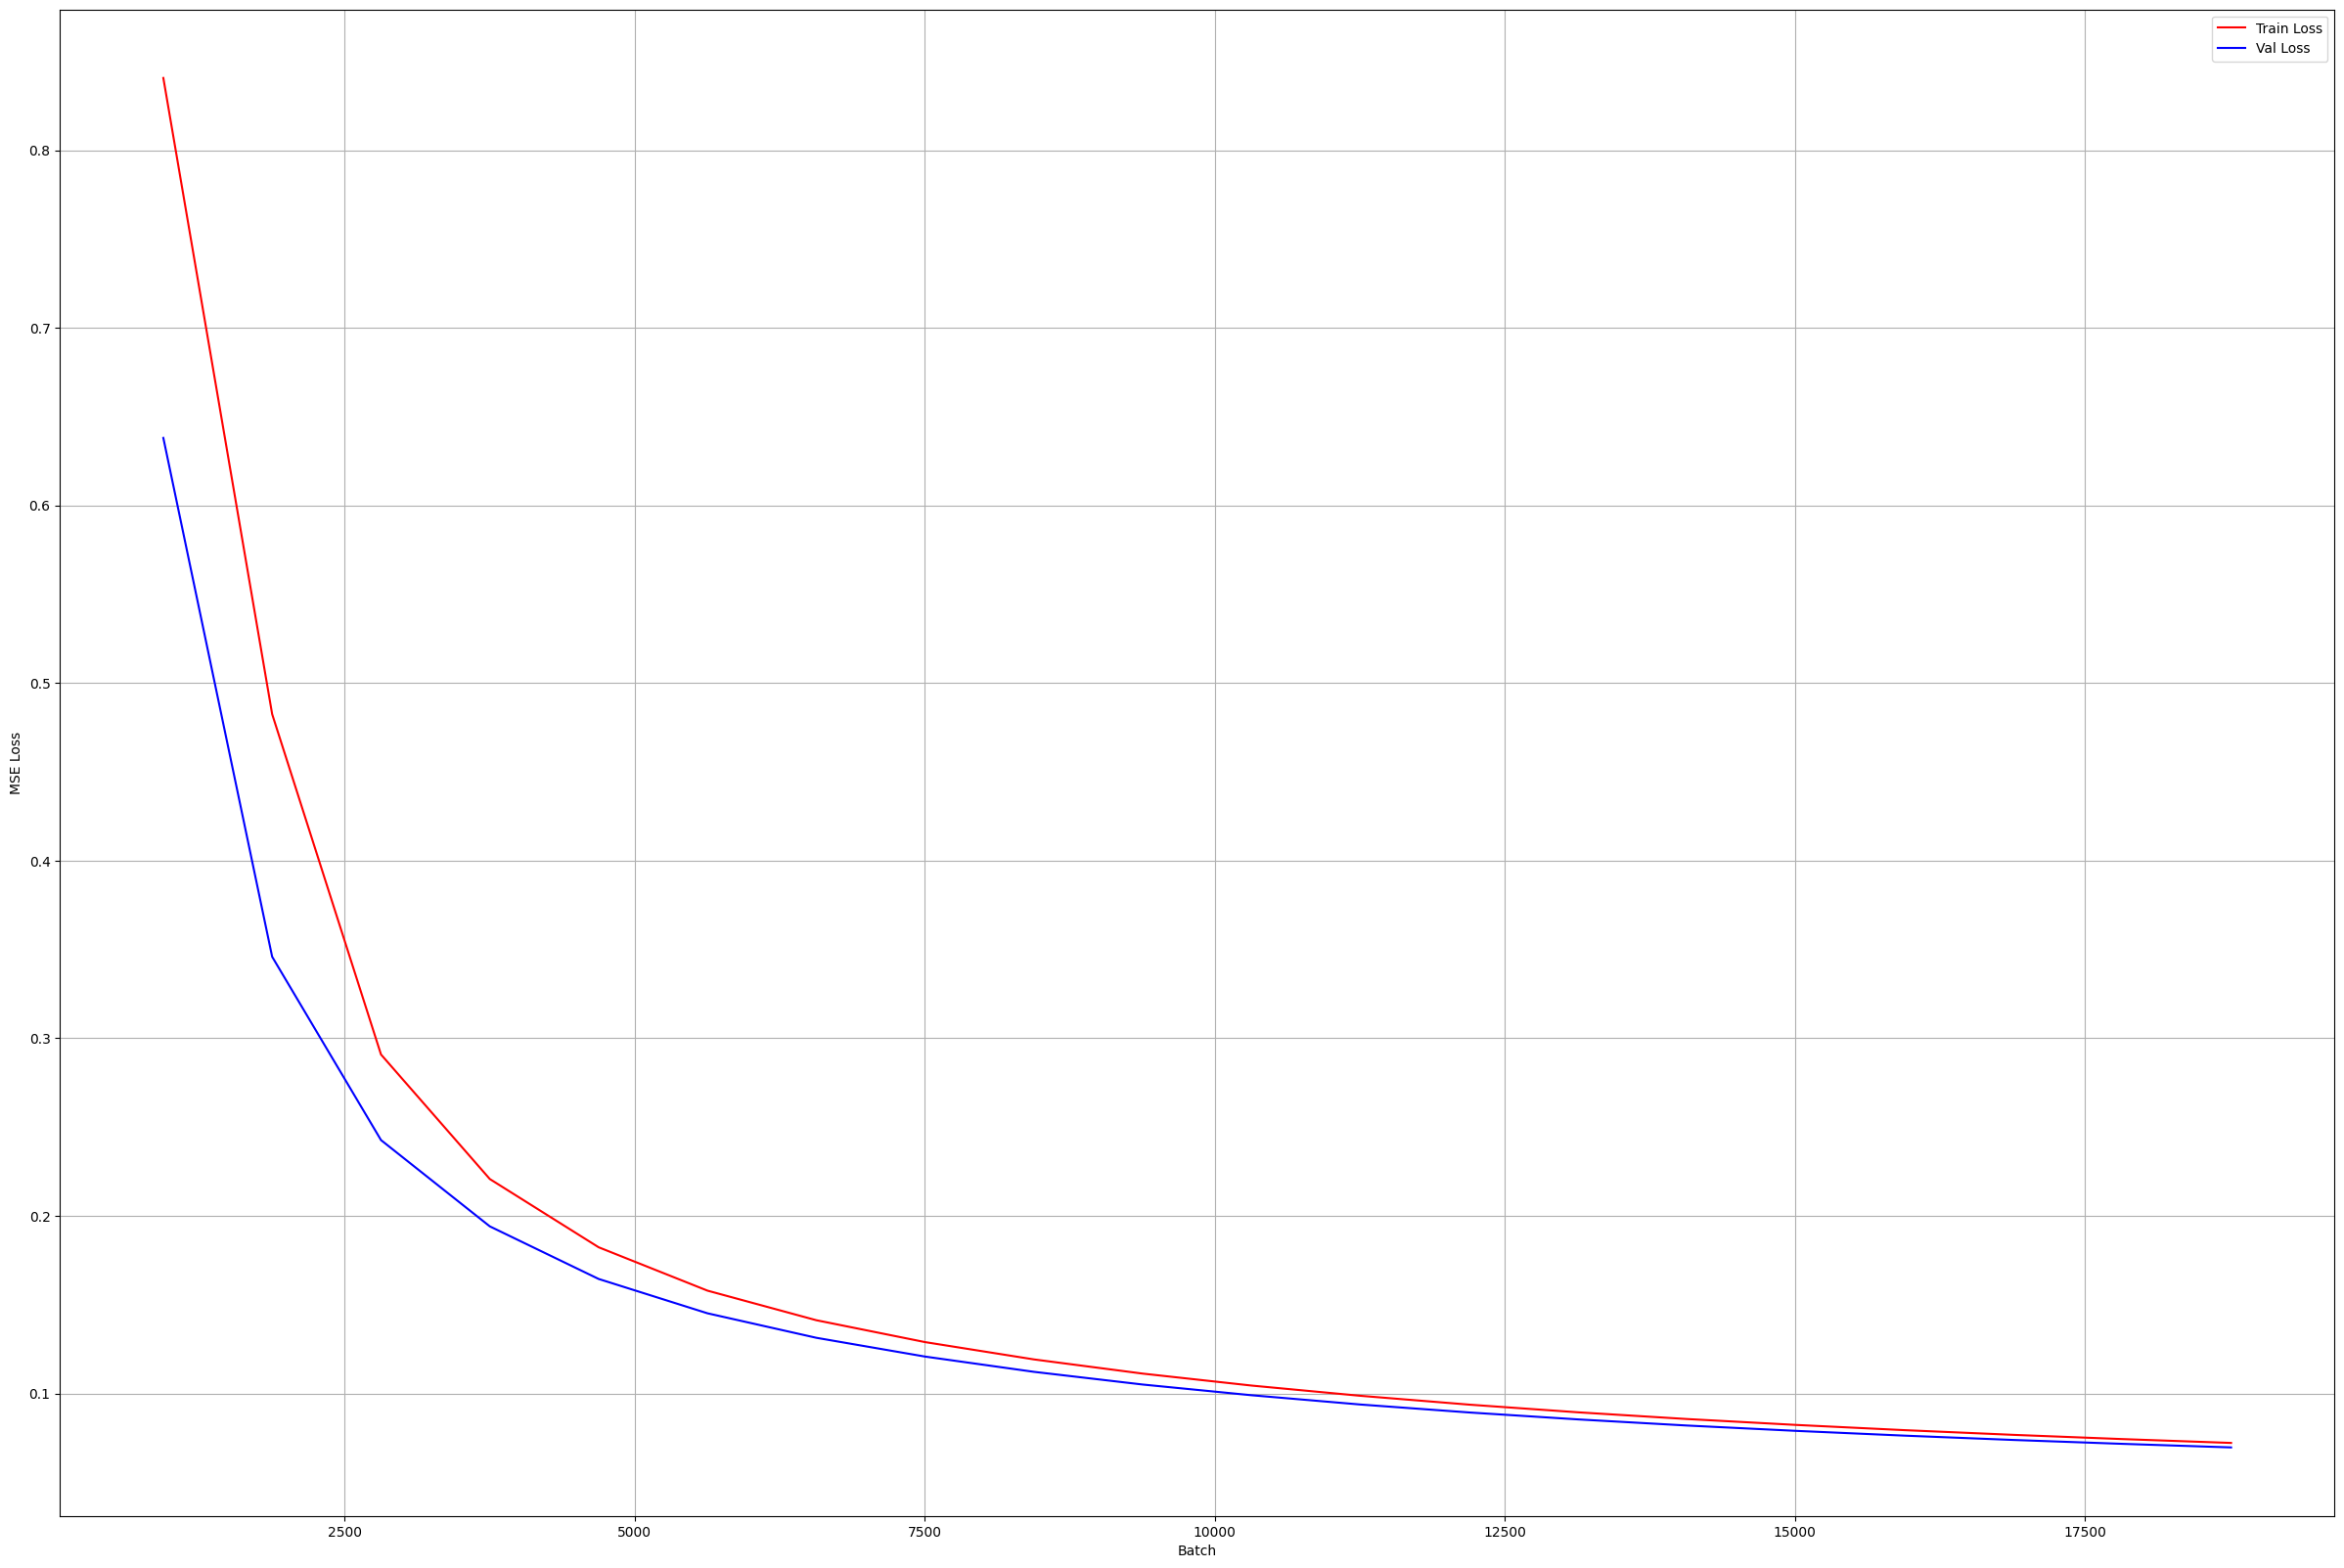

In [17]:
# Once the model roughly works I need to plot loss changes and determine over or under
# fitting
fig, ax = plt.subplots(figsize=[30, 20])
batch_counts = np.arange(train_batches, train_batches*n_epochs + 1, train_batches)
train = ax.plot(batch_counts, train_means.ravel(), color='red', label='Train Loss')
test = ax.plot(batch_counts, test_means.ravel(), color='blue', label='Val Loss')
ax.legend()
ax.set(xlabel='Batch', ylabel='MSE Loss')
ax.grid()

In [ ]:
torch.save(autoencoder.state_dict(), '../models/autoencoder_v2/checkpoint_epoch_20.pt')